In [2]:
# --- CELL 1: INSTALL & IMPORTS ---
!pip install hyperopt -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time
import os

# Hyperopt Libraries
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll.base import scope

# ML & Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_curve, auc, precision_recall_curve

# Deep Learning
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.backend import clear_session

sns.set_style("whitegrid")
print(f" Libraries Ready. TensorFlow: {tf.__version__}")

 Libraries Ready. TensorFlow: 2.19.0


In [3]:
# --- CELL 2: DATA PREPARATION (FULL DATA) ---
print(" Veri Hazırlanıyor (TÜM VERİ)...")
df = pd.read_csv("urban_building_stock_datasets_17042024.csv")

# Leakage Temizliği
leakage_cols = ['Total_Heating_Energy', 'Interior_Lighting_Energy', 'Interior_Equipment_Energy',
                'Heating_Energy', 'Photovoltaic_Power', 'Total_Electricity_Energy',
                'Energy_Use_Intensity', 'Water_Systems_Energy', 'Building_Energy_Rating',
                'Electricity_Primary_Conversion_Factor', 'Heating_Primary_Conversion_Factor']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

target = "Simple_Building_Energy_Rating"
X = df.drop(columns=[target])
y = df[target].copy()

# Feature Engineering
X["Global_U_Value"] = (X["Window_Insulation_U-Value"] * X["Window_to_Wall_Ratio"] +
                        X["Wall_Insulation_U-Value"] * (1 - X["Window_to_Wall_Ratio"]))
X["Thermostat_Delta"] = X["Heating_Setpoint_Temperature"] - X["Heating_Setback_Temperature"]
X["Internal_Load_Score"] = (X["Lighting_Density"] + X["Equipment_Density"] +
                            (X["Occupancy_Level"] * 100 / (X["Total_Building_Area"] + 1)))
X["HVAC_Load_Factor"] = X["Total_Building_Area"] / (X["HVAC_Efficiency"] + 0.1)
X["Infiltration_Loss_Potential"] = (X["Air_Change_Rate"] * X["Total_Building_Area"] * X["Thermostat_Delta"])
X["Weighted_Roof_U"] = X["Total_Building_Area"] * X["Roof_Insulation_U-Value"]
X["Orientation_Sin"] = np.sin(np.deg2rad(X["Building_Orientation"]))
X["Orientation_Cos"] = np.cos(np.deg2rad(X["Building_Orientation"]))
X = X.drop(columns=["Building_Orientation"])

# Preprocessing
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# Split
# Stratify kullanarak sınıf dengesini koruyoruz
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Transformasyon (Dönüştürme)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# One-Hot Encoding
y_train_oh = to_categorical(y_train, n_classes)
y_test_oh = to_categorical(y_test, n_classes)


X_hpo = X_train
y_hpo = y_train_oh

print(f" Veri Hazır (FULL DATA).")
print(f"Eğitim Seti (Train): {X_train.shape}")

 Veri Hazırlanıyor (TÜM VERİ)...
 Veri Hazır (FULL DATA).
Eğitim Seti (Train): (838849, 31)


In [4]:
# --- CELL 3: MODEL BUILDER & HYPEROPT OBJECTIVE ---

# Model Kurucu Fonksiyon
def build_model(params):
    inputs = Input(shape=(X_hpo.shape[1],))

    # Parametreleri al (Hyperopt bazen float döndürür, int'e çeviriyoruz)
    units = int(params['units'])
    n_layers = int(params['n_layers'])
    dropout_rate = params['dropout']
    activation = params['activation']
    lr = params['learning_rate']
    opt_name = params['optimizer']

    # Giriş Katmanı
    x = Dense(units, kernel_regularizer=l2(0.0001))(inputs)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    x = Dropout(dropout_rate)(x)

    # ResNet Blokları
    for _ in range(n_layers):
        shortcut = x
        x = Dense(units, kernel_regularizer=l2(0.0001))(x)
        x = BatchNormalization()(x)
        x = Activation(activation)(x)
        x = Dropout(dropout_rate)(x)
        x = Add()([x, shortcut])
        x = Activation(activation)(x)

    outputs = Dense(n_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)

    # Optimizer Seçimi
    if opt_name == 'adam': opt = Adam(learning_rate=lr)
    else: opt = RMSprop(learning_rate=lr)

    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

# Hyperopt Amaç Fonksiyonu
def objective(params):
    clear_session()
    model = build_model(params)

    history = model.fit(
        X_hpo, y_hpo,
        epochs=5,
        batch_size=int(params['batch_size']),
        verbose=0,
        validation_split=0.2
    )

    # Hyperopt 'loss' değerini minimize etmeye çalışır.
    # Biz Accuracy'yi maksimize etmek istiyoruz, bu yüzden (1 - Accuracy) döndürüyoruz.
    # Veya en iyi 'val_loss' değerini de döndürebiliriz.
    val_acc = max(history.history['val_accuracy'])

    return {'loss': -val_acc, 'status': STATUS_OK} # -val_acc minimize edilir -> acc maximize edilir

print(" Hyperopt Fonksiyonları Hazır.")

 Hyperopt Fonksiyonları Hazır.


In [5]:
# --- CELL 4: RUNNING HYPEROPT ---
print("\n🔍 Hyperopt (TPE) Optimizasyonu Başlıyor...")
start_time = time.time()


space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.0001), np.log(0.01)),
    'batch_size': hp.choice('batch_size', [256, 512, 1024]),
    'n_layers': hp.quniform('n_layers', 2, 4, 1),      # 2, 3, 4
    'units': hp.quniform('units', 64, 1024, 64),       # 64'ten 1024'e 64'er
    'activation': hp.choice('activation', ['relu', 'swish']),
    'optimizer': hp.choice('optimizer', ['adam', 'rmsprop']),
    'dropout': hp.uniform('dropout', 0.0, 0.5)
}

# Optimizasyonu Başlat
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest, # Tree-structured Parzen Estimator
    max_evals=30,
    trials=trials
)

runtime = time.time() - start_time

# hp.choice indeks döndürür, bunları gerçek değerlere çevirmeliyiz
batch_list = [256, 512, 1024]
act_list = ['relu', 'swish']
opt_list = ['adam', 'rmsprop']

# En iyi parametreleri formatla
best_params = {
    'learning_rate': best['learning_rate'],
    'batch_size': batch_list[best['batch_size']],
    'n_layers': int(best['n_layers']),
    'units': int(best['units']),
    'activation': act_list[best['activation']],
    'optimizer': opt_list[best['optimizer']],
    'dropout': best['dropout']
}

print(f"\n Hyperopt Süresi: {runtime/60:.2f} dakika")
print("\n KAZANAN PARAMETRELER:")
print(best_params)


🔍 Hyperopt (TPE) Optimizasyonu Başlıyor...
100%|██████████| 30/30 [26:02<00:00, 52.08s/trial, best loss: -0.8390713334083557]

 Hyperopt Süresi: 26.04 dakika

 KAZANAN PARAMETRELER:
{'learning_rate': np.float64(0.000674289500257529), 'batch_size': 512, 'n_layers': 3, 'units': 384, 'activation': 'relu', 'optimizer': 'adam', 'dropout': np.float64(0.005684569598789768)}


In [6]:
# --- CELL 5: FINAL TRAINING ---
print("\n Final Model Eğitimi Başlıyor (Hyperopt Parametreleri ile)...")
train_start = time.time()

# 1. Focal Loss Fonksiyonu
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

# 2. Modeli Kurma
clear_session()
inputs = Input(shape=(X_train.shape[1],))

# Hyperopt'tan gelen en iyi parametreleri alıyoruz
units = int(best_params['units'])
act = best_params['activation']
drop = best_params['dropout']
layers = int(best_params['n_layers'])
lr = best_params['learning_rate']

# Giriş Katmanı
x = Dense(units, kernel_regularizer=l2(0.0001))(inputs)
x = BatchNormalization()(x)
x = Activation(act)(x)
x = Dropout(drop)(x)

# Residual Bloklar
for _ in range(layers):
    shortcut = x
    x = Dense(units, kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Activation(act)(x)
    x = Dropout(drop)(x)
    x = Add()([x, shortcut])
    x = Activation(act)(x)

outputs = Dense(n_classes, activation='softmax')(x)
final_model = Model(inputs=inputs, outputs=outputs)

# Optimizer Ayarı
if best_params['optimizer'] == 'adam':
    opt = Adam(learning_rate=lr)
else:
    opt = RMSprop(learning_rate=lr)

final_model.compile(loss=categorical_focal_loss(), optimizer=opt, metrics=['accuracy'])

# 3. Eğitim
history = final_model.fit(
    X_train, y_train_oh,
    validation_data=(X_test, y_test_oh),
    epochs=100,
    batch_size=int(best_params['batch_size']),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
        ModelCheckpoint("final_hyperopt_model.keras", save_best_only=True, monitor='val_accuracy', mode='max')
    ],
    verbose=1
)

train_time = time.time() - train_start
print(f" Eğitim Tamamlandı. Süre: {train_time/60:.2f} dakika")


 Final Model Eğitimi Başlıyor (Hyperopt Parametreleri ile)...
Epoch 1/100
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.7268 - loss: 0.1697 - val_accuracy: 0.7839 - val_loss: 0.0724 - learning_rate: 6.7429e-04
Epoch 2/100
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7880 - loss: 0.0629 - val_accuracy: 0.8175 - val_loss: 0.0449 - learning_rate: 6.7429e-04
Epoch 3/100
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8051 - loss: 0.0477 - val_accuracy: 0.8131 - val_loss: 0.0458 - learning_rate: 6.7429e-04
Epoch 4/100
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8085 - loss: 0.0447 - val_accuracy: 0.8205 - val_loss: 0.0406 - learning_rate: 6.7429e-04
Epoch 5/100
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8118 - loss: 0.0429 - val_accuracy: 0.8179 - val_loss: 0.0407 - learning_rate: 6.7429e-04
Epoch 6/100
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8191 - loss: 0.0407 - val_accuracy: 0.8334 - val_loss: 0.0368 - learni

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           A     0.9787    0.9701    0.9744     43777
           B     0.9363    0.9335    0.9349     54258
           C     0.9114    0.9210    0.9162     54852
           D     0.8626    0.8615    0.8621     26453
           E     0.8364    0.8314    0.8339     14131
           F     0.7690    0.7751    0.7720      6655
           G     0.9307    0.9345    0.9326      9587

    accuracy                         0.9169    209713
   macro avg     0.8893    0.8896    0.8894    209713
weighted avg     0.9171    0.9169    0.9170    209713



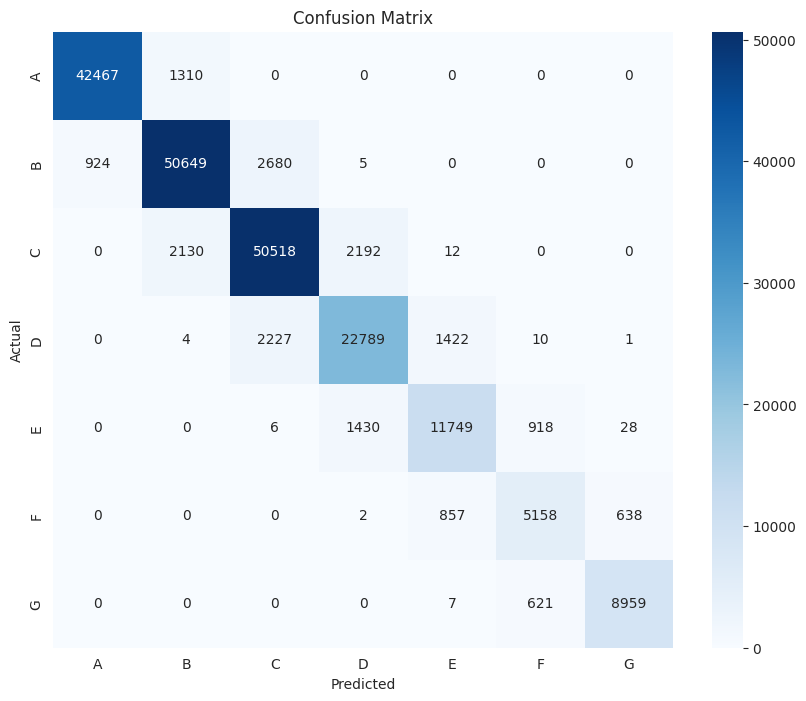

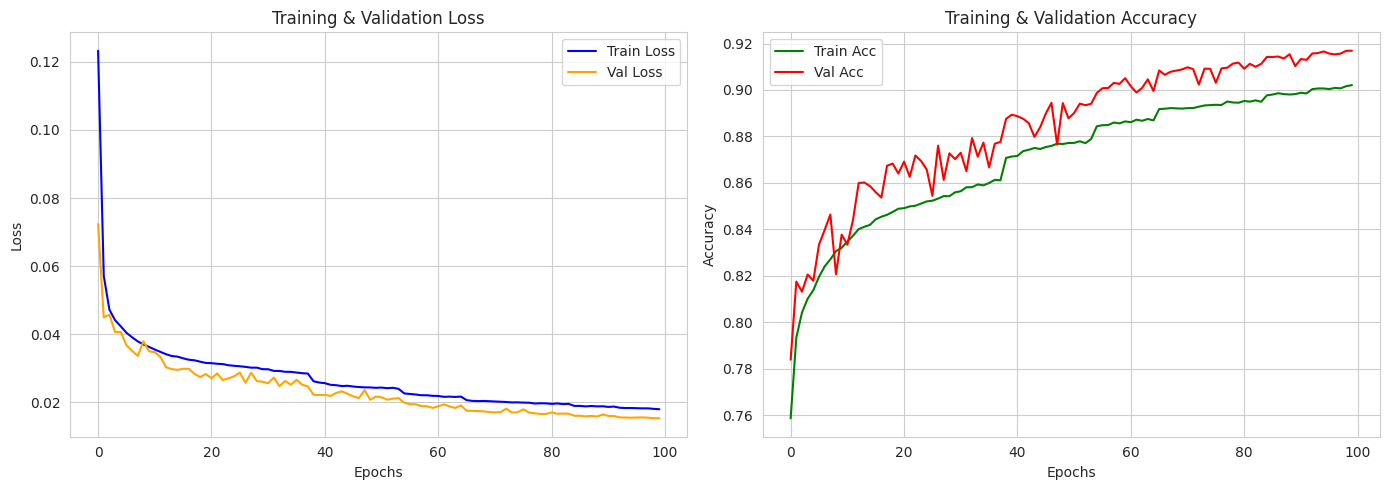


 Cohen's Kappa Score: 0.8958
 HPO Runtime: 26.04 min
 Training Runtime: 13.83 min


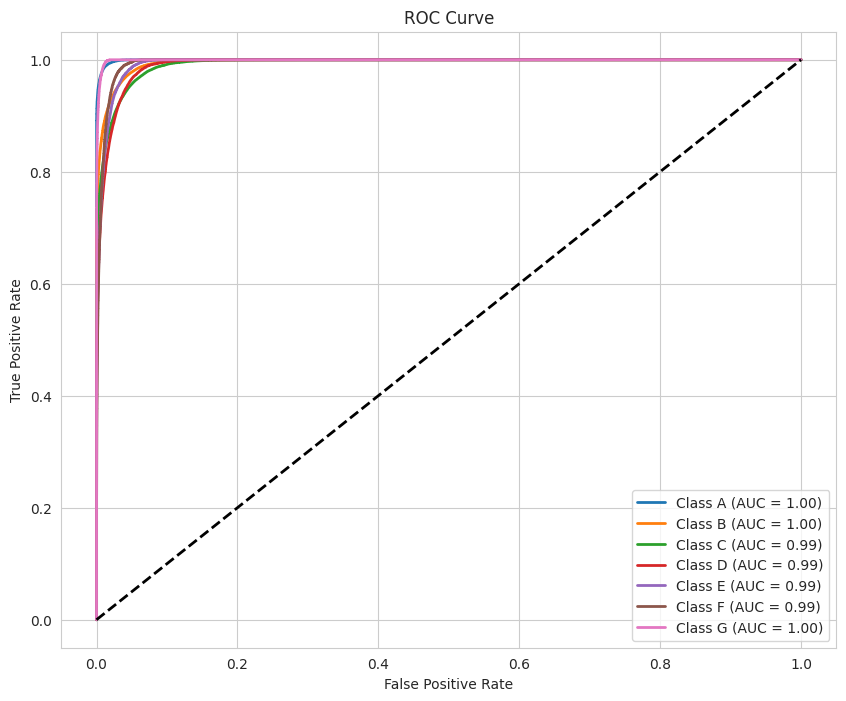

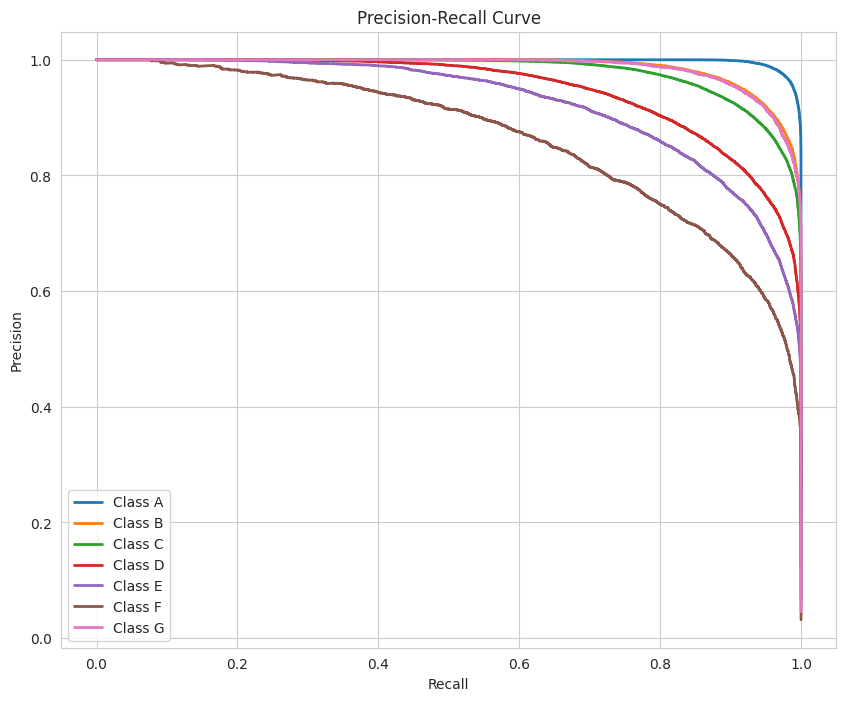

In [7]:
# --- CELL 6: REPORTING & PLOTS ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Tahminler
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- Classification Report ---")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes,
        digits=4
    )
)


# 2. Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. Training Curves (Loss & Accuracy)
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='green')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='red')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 4. Metrics & Runtimes
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\n Cohen's Kappa Score: {kappa:.4f}")
# runtime değişkeni HPO hücresinden, train_time bu hücreden geliyor
print(f" HPO Runtime: {runtime/60:.2f} min")
print(f" Training Runtime: {train_time/60:.2f} min")

# 5. ROC Curve
plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_test, classes=range(n_classes))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# 6. Precision-Recall Curve
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {classes[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="best")
plt.show()